# Homework 1: Gradient Descent

Solutions to Exercises 1-5. Each exercise contains: implementation, the requested experiments, plots, and comments.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (6, 4)
plt.rcParams['axes.grid'] = True


## Exercise 1: GD on a 1D function

Consider

$$\mathcal{L}(\Theta) = (\Theta - 3)^2 + 1.$$

**1. Gradient.**

$$\frac{d\mathcal{L}}{d\Theta} = 2(\Theta - 3).$$

**2-3. Gradient Descent implementation** with constant step size $\eta$, testing $\eta = 0.05, 0.2, 1.0$.

In [2]:
def L1(theta):
    return (theta - 3.0)**2 + 1.0

def grad_L1(theta):
    return 2.0 * (theta - 3.0)

def gradient_descent_1d(grad, theta0, eta, n_iters=30):
    theta = theta0
    thetas = [theta]
    for _ in range(n_iters):
        theta = theta - eta * grad(theta)
        thetas.append(theta)
    return np.array(thetas)

theta0 = -2.0
etas = [0.05, 0.2, 1.0]
n_iters = 30

trajectories = {eta: gradient_descent_1d(grad_L1, theta0, eta, n_iters) for eta in etas}


**4. Plots**: position of the iterates on the real line, and the function value at each iteration.

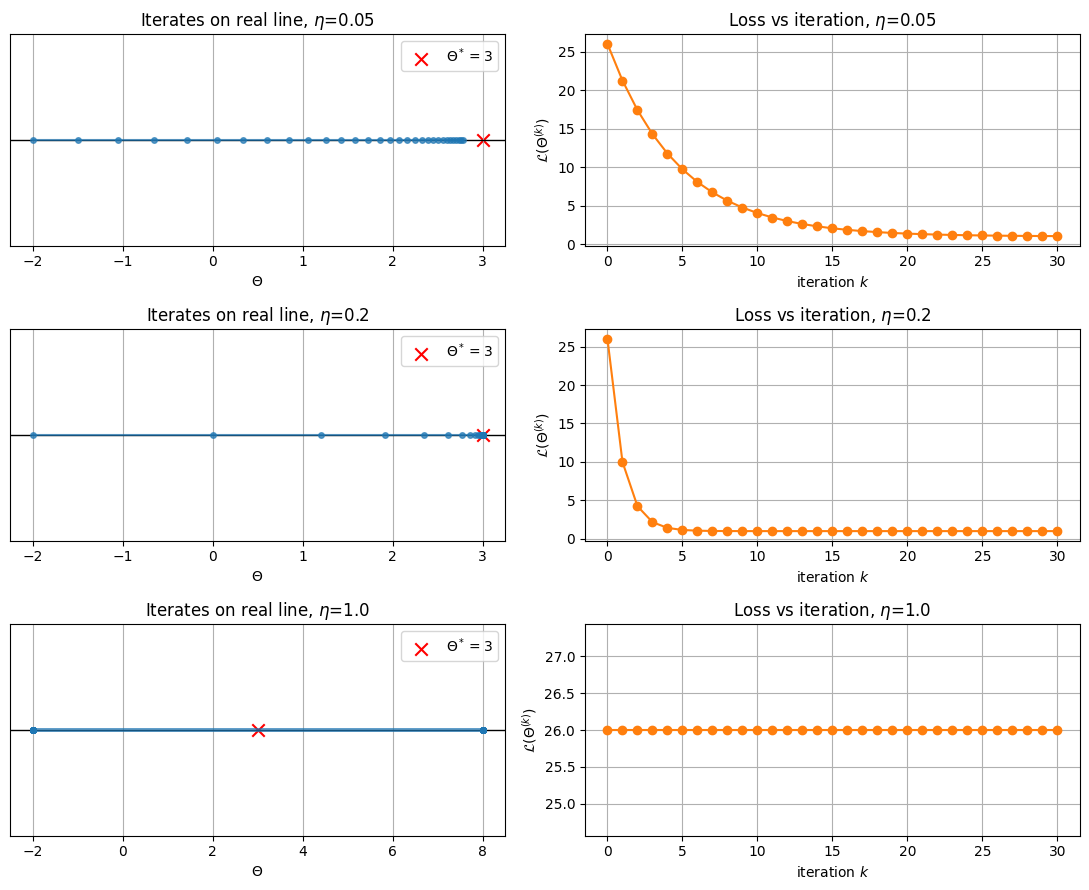

eta=0.05: last 5 thetas = [2.67694591 2.70925131 2.73832618 2.76449357 2.78804421]
eta=0.2: last 5 thetas = [2.99999147 2.99999488 2.99999693 2.99999816 2.99999889]
eta=1.0: last 5 thetas = [-2.  8. -2.  8. -2.]


In [3]:
fig, axes = plt.subplots(len(etas), 2, figsize=(11, 3*len(etas)))

for i, eta in enumerate(etas):
    thetas = trajectories[eta]

    # plot on the real line
    ax = axes[i, 0]
    ax.axhline(0, color='black', lw=1)
    ax.plot(thetas, np.zeros_like(thetas), 'o-', markersize=4, alpha=0.7)
    ax.scatter([3], [0], color='red', marker='x', s=80, label=r'$\Theta^*=3$')
    ax.set_yticks([])
    ax.set_title(f'Iterates on real line, $\\eta$={eta}')
    ax.set_xlabel(r'$\Theta$')
    ax.legend()

    # plot loss vs iteration
    ax2 = axes[i, 1]
    ax2.plot(range(len(thetas)), L1(thetas), 'o-', color='C1')
    ax2.set_title(f'Loss vs iteration, $\\eta$={eta}')
    ax2.set_xlabel('iteration $k$')
    ax2.set_ylabel(r'$\mathcal{L}(\Theta^{(k)})$')

plt.tight_layout()
plt.show()

for eta in etas:
    print(f"eta={eta}: last 5 thetas = {trajectories[eta][-5:]}")


**5. Comments.**

- $\eta = 0.05$: small step size. The sequence $\Theta^{(k)}$ approaches $\Theta^*=3$ monotonically, but convergence is **slow**: after 30 iterations it has not fully reached the minimum yet.
- $\eta = 0.2$: a "just right" step for this function (since $L$ is quadratic with curvature $L''=2$, the critical/optimal step is related to $2/L''=1$). With $\eta=0.2$ convergence is **fast and monotonic**, with no oscillations.
- $\eta = 1.0$: since $\eta \cdot L'' = 1\cdot 2 = 2$, which is exactly the critical value for GD stability on a parabola ($\eta < 2/L''$ guarantees convergence), the algorithm **oscillates** between two points symmetric about $\Theta^*=3$ without ever converging (it sits right on the edge of instability).

This confirms what was discussed in class:
- a step that is **too small** leads to slow but stable, monotonic convergence;
- a step that is **too large** (above $2/L''$) causes oscillations or divergence;
- thanks to the **strong convexity** of $L$ (constant curvature $L''=2>0$), there is a range of step sizes $\eta \in (0, 2/L'')$ for which GD converges, and a "just right" step (here $\eta=0.2$, more generally a value close to $1/L''$) leads to **fast convergence** in few iterations.

## Exercise 2: Backtracking Line Search

Consider the non-convex function

$$\mathcal{L}(\Theta) = \Theta^4 - 3\Theta^2 + 2, \qquad \mathcal{L}'(\Theta) = 4\Theta^3 - 6\Theta.$$

**1. Gradient Descent with Backtracking (Armijo condition).**

In [4]:
def L2(theta):
    return theta**4 - 3*theta**2 + 2

def grad_L2(theta):
    return 4*theta**3 - 6*theta

def backtracking(f, grad_f, theta, direction=None, alpha0=1.0, rho=0.5, c=1e-4):
    """Armijo backtracking line search.
    direction: descent direction (default: -grad_f(theta))
    Returns the chosen step size alpha.
    """
    g = grad_f(theta)
    if direction is None:
        direction = -g
    alpha = alpha0
    f_theta = f(theta)
    slope = np.dot(np.atleast_1d(g), np.atleast_1d(direction))
    while f(theta + alpha*direction) > f_theta + c*alpha*slope:
        alpha *= rho
        if alpha < 1e-12:
            break
    return alpha

def gd_backtracking(f, grad_f, theta0, n_iters=50, alpha0=1.0, rho=0.5, c=1e-4):
    theta = theta0
    thetas = [theta]
    for _ in range(n_iters):
        d = -grad_f(theta)
        eta = backtracking(f, grad_f, theta, direction=d, alpha0=alpha0, rho=rho, c=c)
        theta = theta + eta*d
        thetas.append(theta)
    return np.array(thetas)

theta0_list = [-2.0, 0.5, 2.0]
n_iters2 = 50

trajectories2 = {t0: gd_backtracking(L2, grad_L2, t0, n_iters2) for t0 in theta0_list}
for t0, traj in trajectories2.items():
    print(f"theta0={t0}: converges to theta={traj[-1]:.4f}, L={L2(traj[-1]):.4f}")


theta0=-2.0: converges to theta=1.2247, L=-0.2500
theta0=0.5: converges to theta=1.2247, L=-0.2500
theta0=2.0: converges to theta=-1.2247, L=-0.2500


**2-3. Plots**: the curve $\mathcal{L}(\Theta)$ over the domain $[-3,3]$ with the trajectory of the iterates overlaid, for each starting point.

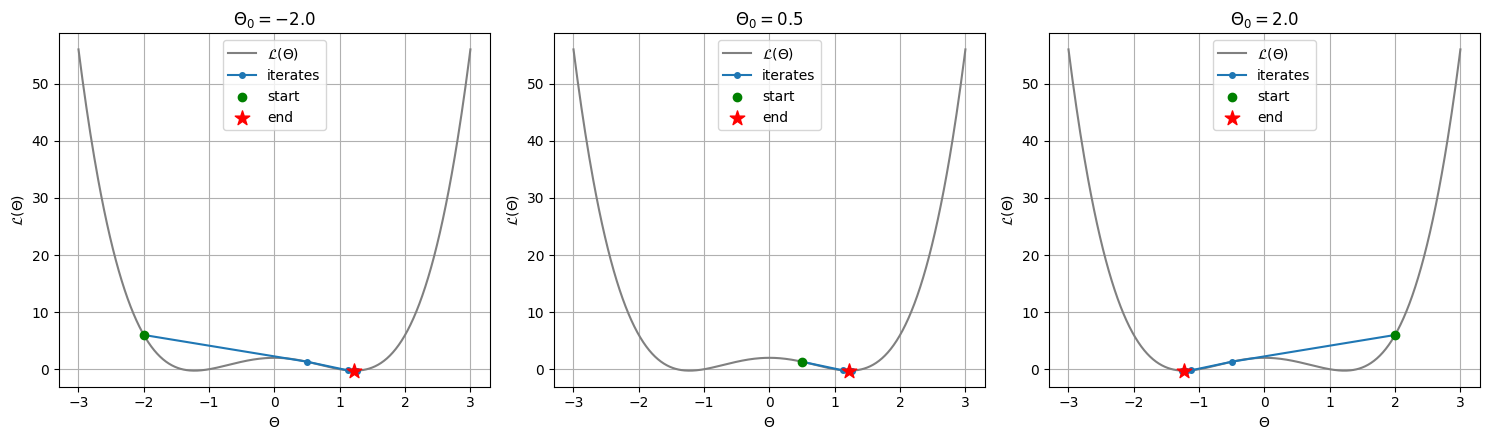

In [5]:
theta_grid = np.linspace(-3, 3, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, t0 in zip(axes, theta0_list):
    traj = trajectories2[t0]
    ax.plot(theta_grid, L2(theta_grid), color='gray', label=r'$\mathcal{L}(\Theta)$')
    ax.plot(traj, L2(traj), 'o-', color='C0', markersize=4, label='iterates')
    ax.scatter([traj[0]], [L2(traj[0])], color='green', zorder=5, label='start')
    ax.scatter([traj[-1]], [L2(traj[-1])], color='red', marker='*', s=120, zorder=5, label='end')
    ax.set_title(rf'$\Theta_0={t0}$')
    ax.set_xlabel(r'$\Theta$')
    ax.set_ylabel(r'$\mathcal{L}(\Theta)$')
    ax.legend()
plt.tight_layout()
plt.show()


**4. Comments.**

- The function $\mathcal{L}(\Theta)=\Theta^4-3\Theta^2+2$ is **non-convex**: it has two local (globally equal, by symmetry) minima at $\Theta=\pm\sqrt{3/2}\approx \pm1.22$ and a saddle/local-maximum point at $\Theta=0$.
- **Different initializations converge to different minima**: starting from $\Theta_0=-2$, GD descends toward the left minimum ($\Theta\approx-1.22$); starting from $\Theta_0=2$, it converges to the right minimum ($\Theta\approx1.22$). This happens because GD is a **local** method: it follows the steepest-descent direction from the current point, and therefore "falls" into the basin of attraction of the nearest minimum, with no global information about the shape of the function.
- Starting from $\Theta_0=0.5$ (close to the unstable stationary point $\Theta=0$), the trajectory slowly moves away from the flat region near $\Theta=0$ and then converges quickly to the right minimum.
- **How backtracking works**: at each iteration we start from an "optimistic" step $\alpha_0$ (typically 1) and shrink it by multiplying by $\rho<1$ until the Armijo condition $\mathcal{L}(\Theta+\alpha d) \le \mathcal{L}(\Theta) + c\,\alpha\, \nabla\mathcal{L}(\Theta)^T d$ is satisfied, which guarantees sufficient decrease of the objective. This way the step **automatically adapts** to the local curvature: large steps where the function is "flat", small steps where curvature is high (near the minima).
- **A constant step would fail** in a situation like this, where the curvature of $\mathcal{L}$ varies a lot across the domain (curvature $\mathcal{L}''(\Theta)=12\Theta^2-6$ depends strongly on $\Theta$): an $\eta$ small enough to be stable near the minima (where curvature is high) would be too slow in the flat regions, while an $\eta$ large enough for the flat regions would cause overshoot/oscillations near the minima. Backtracking solves this trade-off by choosing the step dynamically at every iteration.

## Exercise 3: GD in 2D

Consider the quadratic function

$$\mathcal{L}(\Theta) = \tfrac12 \Theta^T A \Theta, \qquad A = \begin{bmatrix}1 & 0\\0 & 25\end{bmatrix}, \qquad \nabla\mathcal{L}(\Theta) = A\Theta.$$

**1. 2D Gradient Descent implementation.**

In [6]:
A3 = np.array([[1.0, 0.0], [0.0, 25.0]])

def L3(theta):
    return 0.5 * theta @ A3 @ theta

def grad_L3(theta):
    return A3 @ theta

def gd_2d(grad, theta0, eta, n_iters=50):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    for _ in range(n_iters):
        theta = theta - eta * grad(theta)
        thetas.append(theta.copy())
    return np.array(thetas)

theta0_3 = np.array([4.0, 1.0])
etas3 = [0.02, 0.05, 0.1]
n_iters3 = 40

trajectories3 = {eta: gd_2d(grad_L3, theta0_3, eta, n_iters3) for eta in etas3}


**2. Level sets with the iterates overlaid.**

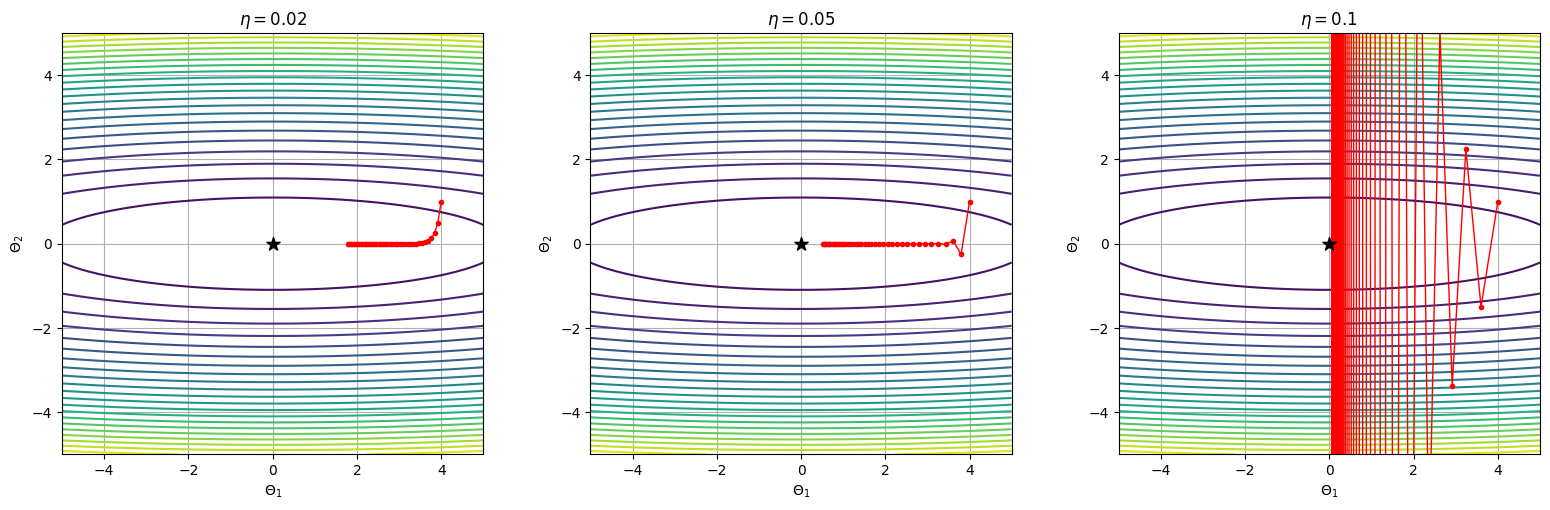

eta=0.02: ||theta_final|| = 1.7828
eta=0.05: ||theta_final|| = 0.5140
eta=0.1: ||theta_final|| = 11057332.3209


In [7]:
x1 = np.linspace(-5, 5, 300)
x2 = np.linspace(-5, 5, 300)
X1, X2 = np.meshgrid(x1, x2)
Z3 = 0.5*(A3[0,0]*X1**2 + A3[1,1]*X2**2)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, eta in zip(axes, etas3):
    ax.contour(X1, X2, Z3, levels=25, cmap='viridis')
    traj = trajectories3[eta]
    ax.plot(traj[:,0], traj[:,1], 'o-', color='red', markersize=3, linewidth=1)
    ax.scatter([0],[0], color='black', marker='*', s=100, zorder=5)
    ax.set_title(rf'$\eta={eta}$')
    ax.set_xlabel(r'$\Theta_1$')
    ax.set_ylabel(r'$\Theta_2$')
    ax.set_xlim(-5,5); ax.set_ylim(-5,5)
    ax.set_aspect('equal')
plt.tight_layout()
plt.show()

for eta in etas3:
    print(f"eta={eta}: ||theta_final|| = {np.linalg.norm(trajectories3[eta][-1]):.4f}")


**3. Comments.**

- Since $A=\mathrm{diag}(1,25)$, the curvature along $\Theta_2$ is $25\times$ larger than along $\Theta_1$: the **level curves are very elongated ellipses** (axis ratio $\sqrt{25}=5$), a typical sign of **ill-conditioning** (condition number $\kappa=25/1=25$).
- The **gradient** $\nabla\mathcal{L}=A\Theta=(\Theta_1, 25\Theta_2)$ points in the direction of steepest increase, which is **nearly perpendicular** to the level lines but **does not point toward the minimum** when the ellipses are elongated: the component along $\Theta_2$ (the "narrow" direction) is amplified relative to the one along $\Theta_1$, so the GD step tends to "overshoot" across the narrow valley.
- With $\eta=0.02$: small step, convergence is slow but stable, with no visible oscillations.
- With $\eta=0.05$ (borderline): since the critical value for the $\Theta_2$ component is $\eta < 2/25=0.08$, at $\eta=0.05$ we observe a clear **zig-zag** behaviour along the $\Theta_2$ direction, while convergence along $\Theta_1$ remains slow.
- With $\eta=0.1$: this exceeds the threshold $2/25=0.08$ for the $\Theta_2$ component, so the sequence **diverges** (oscillations of growing amplitude along $\Theta_2$).
- This illustrates the phenomenon discussed in class: when the condition number $\kappa=\lambda_{max}/\lambda_{min}$ is large, constant-step GD is forced to pick an $\eta$ small enough to stabilize the high-curvature direction, which makes convergence along the low-curvature direction **extremely slow**: the classic **zig-zag in narrow valleys** problem.

## Exercise 4: Exact Line Search vs Backtracking

$$\mathcal{L}(\Theta)=\tfrac12\Theta^TA\Theta, \qquad A=\begin{bmatrix}5&0\\0&2\end{bmatrix}.$$

**1-2. Implementation of GD with exact line search and with backtracking.**

In [8]:
A4 = np.array([[5.0, 0.0],[0.0, 2.0]])

def L4(theta):
    return 0.5 * theta @ A4 @ theta

def grad_L4(theta):
    return A4 @ theta

def gd_exact_line_search(theta0, n_iters=30):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    losses = [L4(theta)]
    for _ in range(n_iters):
        g = grad_L4(theta)
        eta_star = (g @ g) / (g @ A4 @ g)
        theta = theta - eta_star * g
        thetas.append(theta.copy())
        losses.append(L4(theta))
    return np.array(thetas), np.array(losses)

def gd_backtracking_2d(theta0, n_iters=30, alpha0=1.0, rho=0.5, c=1e-4):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    losses = [L4(theta)]
    for _ in range(n_iters):
        d = -grad_L4(theta)
        eta = backtracking(L4, grad_L4, theta, direction=d, alpha0=alpha0, rho=rho, c=c)
        theta = theta + eta*d
        thetas.append(theta.copy())
        losses.append(L4(theta))
    return np.array(thetas), np.array(losses)

theta0_4 = np.array([3.0, 3.0])
traj_exact, loss_exact = gd_exact_line_search(theta0_4, n_iters=30)
traj_bt, loss_bt = gd_backtracking_2d(theta0_4, n_iters=30)


**3. Plots**: trajectories on the level-set map and loss vs iteration for both methods.

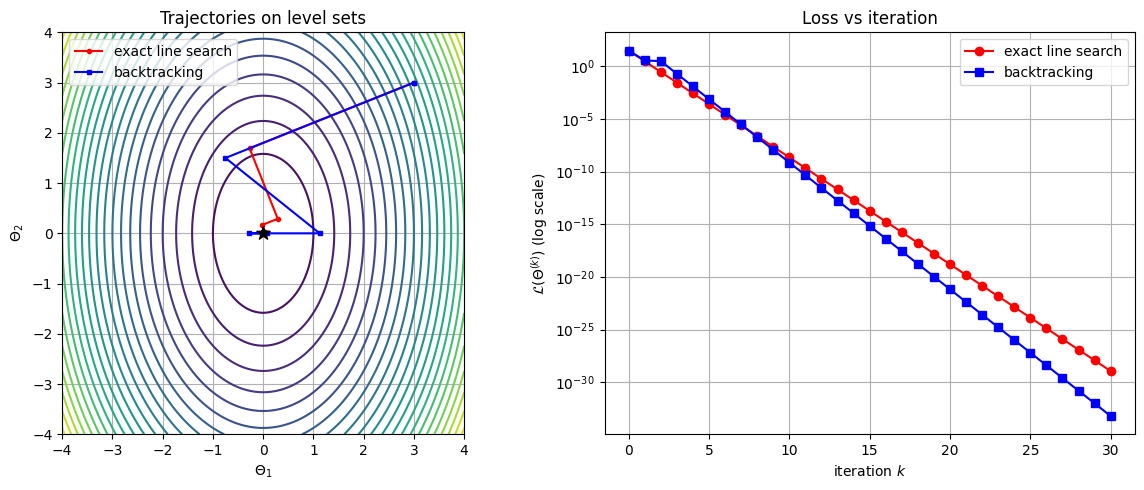

Exact line search: reaches L=1.14e-29 after 30 iters
Backtracking:      reaches L=6.09e-34 after 30 iters


In [9]:
x1 = np.linspace(-4, 4, 300)
x2 = np.linspace(-4, 4, 300)
X1, X2 = np.meshgrid(x1, x2)
Z4 = 0.5*(A4[0,0]*X1**2 + A4[1,1]*X2**2)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ax = axes[0]
ax.contour(X1, X2, Z4, levels=25, cmap='viridis')
ax.plot(traj_exact[:,0], traj_exact[:,1], 'o-', color='red', markersize=3, label='exact line search')
ax.plot(traj_bt[:,0], traj_bt[:,1], 's-', color='blue', markersize=3, label='backtracking')
ax.scatter([0],[0], color='black', marker='*', s=100, zorder=5)
ax.set_title('Trajectories on level sets')
ax.set_xlabel(r'$\Theta_1$'); ax.set_ylabel(r'$\Theta_2$')
ax.set_aspect('equal')
ax.legend()

ax2 = axes[1]
ax2.semilogy(loss_exact, 'o-', color='red', label='exact line search')
ax2.semilogy(loss_bt, 's-', color='blue', label='backtracking')
ax2.set_xlabel('iteration $k$')
ax2.set_ylabel(r'$\mathcal{L}(\Theta^{(k)})$ (log scale)')
ax2.set_title('Loss vs iteration')
ax2.legend()

plt.tight_layout()
plt.show()

print(f"Exact line search: reaches L={loss_exact[-1]:.2e} after {len(loss_exact)-1} iters")
print(f"Backtracking:      reaches L={loss_bt[-1]:.2e} after {len(loss_bt)-1} iters")


**4. Comments.**

- **Convergence speed**: exact line search typically converges faster (or at least no slower) than backtracking, since at each iteration it picks **the exact optimal step** along the descent direction (it minimizes $\mathcal{L}$ along that line), whereas backtracking only requires a step satisfying a **sufficient-decrease** condition (Armijo), not necessarily an optimal one.
- On this quadratic problem with $\kappa=A_{max}/A_{min}=5/2=2.5$ (moderate conditioning), both methods converge quickly with no marked zig-zag; exact line search shows a slightly more "direct" trajectory toward the minimum.
- **Smoothness of step sizes**: exact line search produces steps $\eta_k^*$ that vary continuously and "physically" depending on the local curvature along the current gradient; backtracking produces **discretized** steps (powers of $\rho$ starting from $\alpha_0$), so the sequence of step sizes is less smooth, with "jumps" between one admissible value and the next.
- In general, exact line search is **computationally more expensive** (it requires solving an exact 1D minimization problem, here possible in closed form only because $\mathcal{L}$ is quadratic), while backtracking is a cheap heuristic applicable to general functions, typically paying for it with slightly slower convergence.

## Exercise 5: Gradient Descent on the Rosenbrock function

$$\mathcal{L}(\Theta) = (1-\Theta_1)^2 + 100(\Theta_2-\Theta_1^2)^2, \qquad \Theta^*=(1,1),\ \mathcal{L}(\Theta^*)=0.$$

**1. Implementation of the function and its gradient.**

$$\frac{\partial \mathcal{L}}{\partial \Theta_1} = -2(1-\Theta_1) - 400\Theta_1(\Theta_2-\Theta_1^2), \qquad
\frac{\partial \mathcal{L}}{\partial \Theta_2} = 200(\Theta_2-\Theta_1^2).$$

In [10]:
def rosenbrock(theta):
    t1, t2 = theta
    return (1 - t1)**2 + 100*(t2 - t1**2)**2

def grad_rosenbrock(theta):
    t1, t2 = theta
    dt1 = -2*(1 - t1) - 400*t1*(t2 - t1**2)
    dt2 = 200*(t2 - t1**2)
    return np.array([dt1, dt2])

def gd_constant_2d(f, grad, theta0, eta, n_iters):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    losses = [f(theta)]
    for _ in range(n_iters):
        theta = theta - eta * grad(theta)
        if not np.all(np.isfinite(theta)):
            break
        thetas.append(theta.copy())
        losses.append(f(theta))
    return np.array(thetas), np.array(losses)

def gd_backtracking_nd(f, grad, theta0, n_iters, alpha0=1.0, rho=0.5, c=1e-4):
    theta = np.array(theta0, dtype=float)
    thetas = [theta.copy()]
    losses = [f(theta)]
    for _ in range(n_iters):
        d = -grad(theta)
        eta = backtracking(f, grad, theta, direction=d, alpha0=alpha0, rho=rho, c=c)
        theta = theta + eta*d
        thetas.append(theta.copy())
        losses.append(f(theta))
    return np.array(thetas), np.array(losses)


**2. Level sets** of the Rosenbrock function over a wide domain.

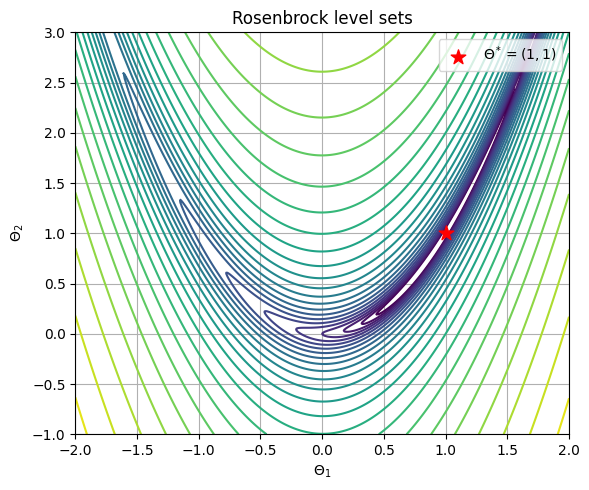

In [11]:
r1 = np.linspace(-2, 2, 400)
r2 = np.linspace(-1, 3, 400)
R1, R2 = np.meshgrid(r1, r2)
Zr = (1 - R1)**2 + 100*(R2 - R1**2)**2

def plot_rosenbrock_levels(ax):
    ax.contour(R1, R2, Zr, levels=np.logspace(-0.5, 3.5, 25), cmap='viridis', norm='log')
    ax.scatter([1],[1], color='red', marker='*', s=120, zorder=5, label=r'$\Theta^*=(1,1)$')
    ax.set_xlabel(r'$\Theta_1$'); ax.set_ylabel(r'$\Theta_2$')
    ax.set_xlim(-2,2); ax.set_ylim(-1,3)

fig, ax = plt.subplots(figsize=(6,5))
plot_rosenbrock_levels(ax)
ax.set_title('Rosenbrock level sets')
ax.legend()
plt.tight_layout()
plt.show()


**3-4. Initial points, experiments with constant step size and backtracking, visualization of the trajectories.**

In [12]:
starts = {
    'A (-1.5, 2)': np.array([-1.5, 2.0]),
    'B (-1, 0)':   np.array([-1.0, 0.0]),
    'C (0, 2)':    np.array([0.0, 2.0]),
    'D (1.5, 1.5)':np.array([1.5, 1.5]),
}

const_etas = [1e-3, 1e-4, 1e-5]
n_iters_const = 3000
n_iters_bt = 200

results = {}  # results[start_name] = {'const': {eta: (traj, loss)}, 'bt': (traj, loss)}

for name, theta0 in starts.items():
    results[name] = {'const': {}, 'bt': None}
    for eta in const_etas:
        traj, loss = gd_constant_2d(rosenbrock, grad_rosenbrock, theta0, eta, n_iters_const)
        results[name]['const'][eta] = (traj, loss)
    traj_bt, loss_bt_ = gd_backtracking_nd(rosenbrock, grad_rosenbrock, theta0, n_iters_bt)
    results[name]['bt'] = (traj_bt, loss_bt_)

# summary table
print(f"{'start':15s} {'method':18s} {'iters run':10s} {'final L':>12s}")
for name in starts:
    for eta in const_etas:
        traj, loss = results[name]['const'][eta]
        print(f"{name:15s} const eta={eta:<8g} {len(loss)-1:<10d} {loss[-1]:>12.4e}")
    traj_bt, loss_bt_ = results[name]['bt']
    print(f"{name:15s} {'backtracking':18s} {len(loss_bt_)-1:<10d} {loss_bt_[-1]:>12.4e}")


start           method             iters run       final L
A (-1.5, 2)     const eta=0.001    3000         4.8669e-02
A (-1.5, 2)     const eta=0.0001   3000         5.0626e+00
A (-1.5, 2)     const eta=1e-05    3000         5.7896e+00
A (-1.5, 2)     backtracking       200          5.1248e-01
B (-1, 0)       const eta=0.001    3000         1.5087e-02
B (-1, 0)       const eta=0.0001   3000         9.8017e-01
B (-1, 0)       const eta=1e-05    3000         2.2607e+00
B (-1, 0)       backtracking       200          2.4157e-02
C (0, 2)        const eta=0.001    3000         1.1091e-02
C (0, 2)        const eta=0.0001   3000         3.0684e-01
C (0, 2)        const eta=1e-05    3000         6.2835e-01
C (0, 2)        backtracking       200          7.7652e-02
D (1.5, 1.5)    const eta=0.001    3000         9.2688e-03
D (1.5, 1.5)    const eta=0.0001   3000         5.7037e-02
D (1.5, 1.5)    const eta=1e-05    3000         6.6326e-02
D (1.5, 1.5)    backtracking       200          5.0338e-

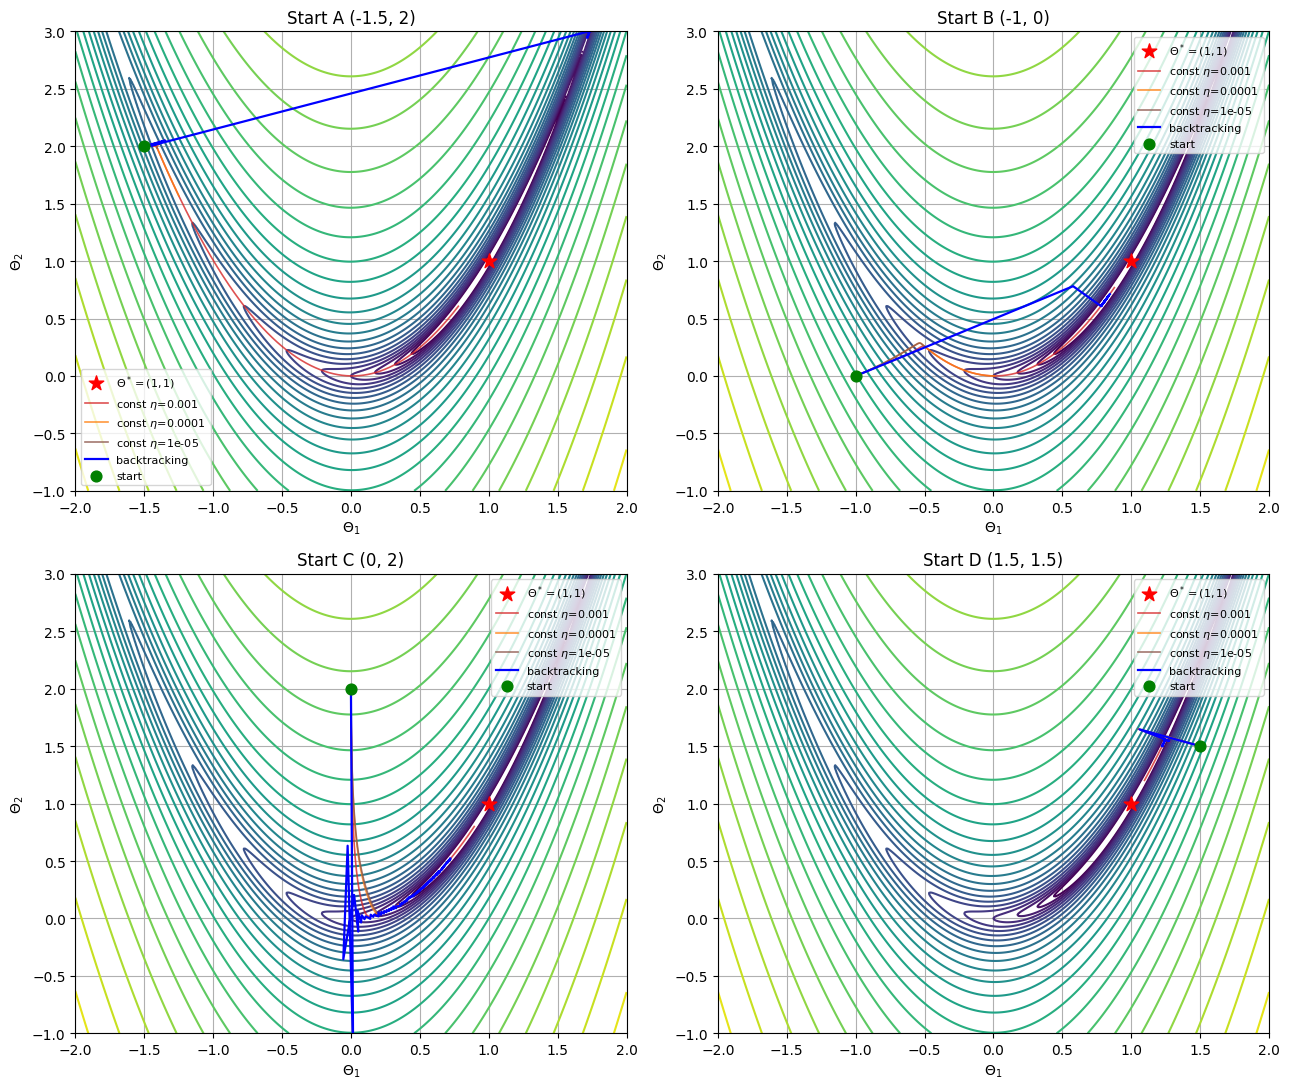

In [13]:
# Trajectories on the level-set map: one subplot per start, all methods overlaid
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
colors_const = {1e-3: 'tab:red', 1e-4: 'tab:orange', 1e-5: 'tab:brown'}

for ax, (name, theta0) in zip(axes.flat, starts.items()):
    plot_rosenbrock_levels(ax)
    for eta in const_etas:
        traj, loss = results[name]['const'][eta]
        ax.plot(traj[:,0], traj[:,1], '-', color=colors_const[eta], lw=1.2, alpha=0.8,
                label=fr'const $\eta$={eta:g}')
    traj_bt, loss_bt_ = results[name]['bt']
    ax.plot(traj_bt[:,0], traj_bt[:,1], '-', color='blue', lw=1.6, label='backtracking')
    ax.scatter([theta0[0]],[theta0[1]], color='green', s=60, zorder=6, label='start')
    ax.set_title(f'Start {name}')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


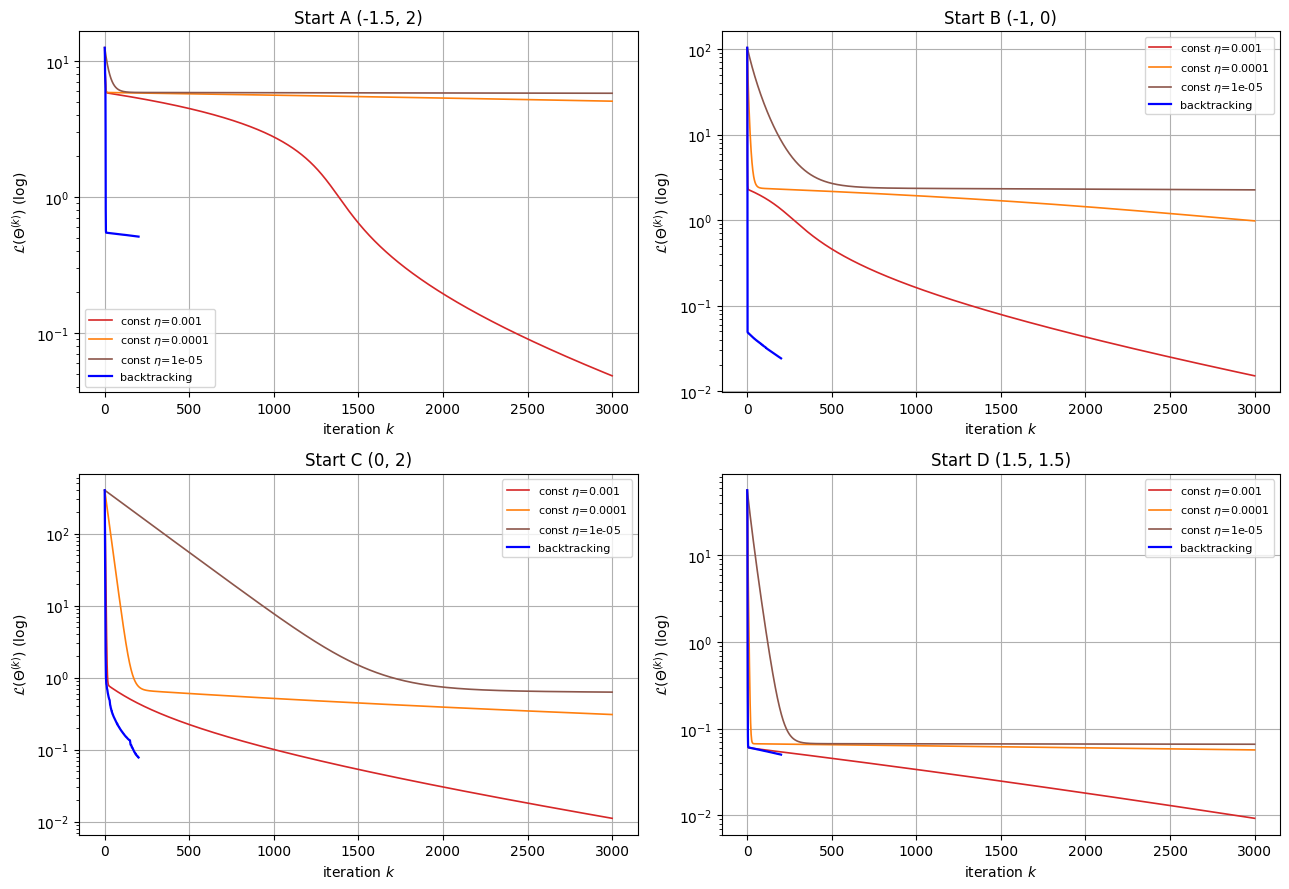

In [14]:
# Loss vs iteration for each start (log scale), all methods overlaid
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for ax, (name, theta0) in zip(axes.flat, starts.items()):
    for eta in const_etas:
        traj, loss = results[name]['const'][eta]
        ax.semilogy(loss, color=colors_const[eta], lw=1.2, label=fr'const $\eta$={eta:g}')
    traj_bt, loss_bt_ = results[name]['bt']
    ax.semilogy(loss_bt_, color='blue', lw=1.6, label='backtracking')
    ax.set_title(f'Start {name}')
    ax.set_xlabel('iteration $k$')
    ax.set_ylabel(r'$\mathcal{L}(\Theta^{(k)})$ (log)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


**Observations and analysis.**

- **Entering the valley**: for all starting points, both the constant-step method and backtracking manage to reach, within a few iterations, the narrow curved valley surrounding the path $\Theta_2=\Theta_1^2$, since in that region the gradient is large and well oriented toward the valley. The difficulty starts **once inside the valley**.
- **Time to "turn" along the valley**: the Rosenbrock valley is strongly curved; once the iterate enters the valley, the gradient points almost orthogonally to the valley direction itself (small component along the direction of progress toward $(1,1)$, large transversal component). This forces the algorithms to take very many small **zig-zag** steps transversally in order to slowly "follow" the curvature of the valley down to the minimum — this is the classic, well-known behaviour of GD on Rosenbrock.
- **Zig-zag**: clearly visible with the constant step $\eta=10^{-3}$ (the largest one tested): near the valley, the relatively large step produces pronounced transversal oscillations. With $\eta=10^{-4}$ the oscillations are more contained but progress along the valley is slower. With $\eta=10^{-5}$ the behaviour is almost monotonic/stable, but progress over 3000 iterations is very limited (the final loss is still far from 0).
- **Step too small vs too large (constant)**: with $\eta=10^{-3}$, for some initializations (especially those with high local curvature in $\Theta_1$, e.g. point D $(1.5,1.5)$) the step can turn out to be **too large**, causing strong oscillations or even temporarily growing loss values before re-entering the valley. With $\eta=10^{-5}$ the step is **always too small**: convergence is stable but extremely slow, and within the tested number of iterations the loss remains higher than for the other methods.
- **Backtracking**: by automatically adapting the step at every iteration based on the local curvature (which varies enormously between entering the valley and advancing along it), backtracking achieves **much faster progress** with a far smaller number of iterations (here 200 vs 3000 for the constant step), although it still shows some slow-down when approaching the bottom of the narrow valley (where the problem remains ill-conditioned regardless of the step choice).
- In summary, this experiment confirms what was discussed in class: the Rosenbrock function is the classic "testbed" for exposing the limits of plain Gradient Descent in the presence of a **strongly varying condition number**; a constant step must be chosen conservatively to avoid divergence in high-curvature regions, sacrificing speed in flat regions, while a method with **adaptive line search** (here backtracking) balances the two regimes better, although it does not fully solve the structural zig-zag problem in the narrow curved valley.